|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The arithmetic<h1>|
|<h2>Lecture:</h2>|<h1><b>The KV cache, in bytes per token<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# The other user of memory

The weights do not change. You pay for them once. Every user then shares them.

The KV cache is different. It grows with every token, for every sequence, and
nobody shares it. The cache is the reason you cannot raise the batch size
until it reaches the ridge point.

In [2]:
# Llama-3-8B
layers   = 32
kv_heads =  8          # not 32. Grouped-query attention.
head_dim = 128
dtype_bytes  =  2          # bf16

per_token = 2 * layers * kv_heads * head_dim * dtype_bytes     # 2 = one K, one V
print(f'{per_token/1024:.0f} KB of KV cache per token')

128 KB of KV cache per token


In [3]:
for context_len in (512, 2048, 8192, 32768):
  print(f'{context_len:>6} tokens -> {context_len*per_token/1e6:8.1f} MB for ONE sequence')

   512 tokens ->     67.1 MB for ONE sequence
  2048 tokens ->    268.4 MB for ONE sequence
  8192 tokens ->   1073.7 MB for ONE sequence
 32768 tokens ->   4295.0 MB for ONE sequence


### Grouped-query attention is not a detail

Use `num_attention_heads` here instead of `num_key_value_heads`. Your answer
is then wrong by the group factor. On this model that factor is 4.

Designers build modern models around KV pressure. The design shows up here.

In [4]:
without_gqa = 2 * layers * 32 * head_dim * dtype_bytes      # if every query head had its own KV
print(f'without GQA: {without_gqa/1024:.0f} KB/token')
print(f'with GQA:    {per_token/1024:.0f} KB/token   ({without_gqa/per_token:.0f}x less)')

without GQA: 512 KB/token
with GQA:    128 KB/token   (4x less)


# What fits

In [5]:
vram      = 12e9
weights   = 8e9 * 1      # 8B params at fp8
available = vram - weights

print(f'{vram/1e9:.0f} GB card')
print(f'{weights/1e9:.0f} GB of weights')
print(f'{available/1e9:.1f} GB left for KV cache\n')

for context_len in (512, 2048, 8192):
  print(f'at {context_len:>5} tokens of context: {available/(context_len*per_token):5.0f} concurrent sequences')

12 GB card
8 GB of weights
4.0 GB left for KV cache

at   512 tokens of context:    60 concurrent sequences
at  2048 tokens of context:    15 concurrent sequences
at  8192 tokens of context:     4 concurrent sequences


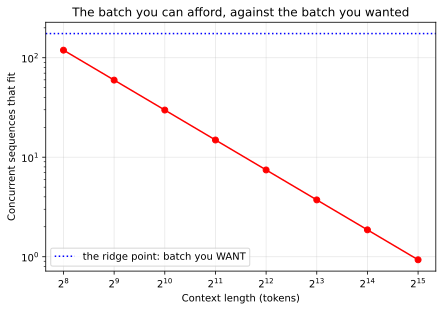

In [6]:
contexts = np.array([256,512,1024,2048,4096,8192,16384,32768])
max_sequences     = available / (contexts * per_token)

plt.figure(figsize=(7,4.5))
plt.plot(contexts, max_sequences, 'ro-')
plt.axhline(175, color='b', ls=':', label='the ridge point: batch you WANT')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Context length (tokens)')
plt.ylabel('Concurrent sequences that fit')
plt.title('The batch you can afford, against the batch you wanted')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### Read the gap

The blue line is the batch size that the last notebook asked for. The red line
is the batch that memory permits.

The two lines cross near a context length of one thousand tokens. Past that
point you must ration memory. The rest of this course lives inside that gap:

- **continuous batching** keeps the slots you hold busy
- **PagedAttention** stops the waste of 60 to 80 percent on reservation
- **prefix sharing** lets two sequences hold the same blocks
- **quantization** makes both lines smaller

This plot also assumes that the engine wastes nothing. Stage 06 measures what
a real contiguous allocator throws away. The answer is most of it.